**ML COURSE 2025-2026**
# Exam simulation

In [ ]:
%cd ..

In [2]:
import numpy as np
import pandas as pd
from dataclasses import dataclass
from matplotlib import pyplot as plt
from tqdm import trange
from scipy import stats

## Outline of the Simulation
1. ID3 Decision Tree on Titanic dataset
    - Implementation of ID3 algorithm (TODO 1)
    - Adaptation to continuous features (TODO 1)
    - Titanic dataset (TODO 2)
2. Regularization (TODO 3)
3. Random Forest: Bootstrap aggregating (TODO 4)
4. Random Forest: Feature bagging (TODO 5, 6)
5. ROC curve on Random Forest and AUROC (TODO 7)
6. ID3 Decision Tree Predict Probabilities (TODO 8)
7. ROC curve on ID3 Decision Tree and AUROC (TODO 9)

## Exercise 1 - Implement a Decision Tree built with ID3

ID3 (Iterative Dichotomiser 3) is a decision tree algorithm, alternative to CART. It was primarly designed for datasets with categorical features. 

<u>Algorithm Overview</u>
- Start with the full dataset $D$ as the root.
- At each node: 
    1. Compute the split entropy or the information gain for each **unused** feature. 
    2. Select the feature with the best impurity value (IG or entropy). 
    3. Split the data based on all possible values of that feature, creating children nodes. 

Note: 
- once a feature is used, it is not reused in descendant nodes.
- each node may have more than 2 children, and also may have just one.

<u> Stopping Conditions (Leaf Nodes)</u>
- No samples at the node → predict the majority class of the parent node. 
- All samples at the node belong to the same class → predict that class.
- No remaining features, but samples belong to multiple classes → predict the majority class


**Handling continous features**  
ID3 was originally designed for categorical features, but it can be adapted to handle continuous features.

**Example of ID3- Decision Tree**

![imageDTID3](https://miro.medium.com/v2/resize:fit:365/1*hyNHuC9L-POy28eSdCubEQ.png)

<span style="color:red"><strong>TODO 1</strong></span>

1. Implement a Decision Tree with ID3 by completing the following structure of the class that can work either with entropy or information gain. 
2. Describe possible adaptations of ID3 to handle continous features. Implement the one you consider most promising. Include an explanation of your reasoning. 

In [3]:
# --- Example of y_subsets used below ---
# Consider the decision tree in the image above. We have a classification task 
# where we want to predict if we can go to play tennis (yes/no)

# at node 0, we select the feature "outlook" to split the data: 
# possible categories are 'sunny', 'overcast', 'rain'
# suppose we have the following training labels for each category: 
y_child1 = ['yes', 'no', 'yes', 'yes']        # outlook sunny
y_child2 = ['yes', 'yes', 'yes']             # outlook overcast
y_child3 = ['no', 'no', 'yes', 'no']         # outlook rain


# we can put all the labels of different children in a list 
# this is a generalization of y_left, y_right of binary split (LAB5)
y_subsets = [y_child1, y_child2, y_child3]     
# if we had 2 children, we would have y_subsets = [y_left, y_right] 

In [4]:
class EntropyCriterion: 
    OPTIMIZATION = "minimize"

    @staticmethod
    def impurity(y): 
        """Entropy is the sum of the probability of each class times the log2 of that probability"""
        class_counts = np.unique(y, return_counts=True)[1]
        probs = class_counts / len(y)
        return -np.sum(probs * np.log2(probs + 1e-16)) 
    
    @staticmethod
    def split_impurity(y_subsets): 
        """Weighted sum of the entropies of the children nodes. 
         
        Args:
            y_subsets: list of arrays, each containing the labels of a child node. 
                     len(y_subsets) = number of children nodes.
        """
        total_labels = len(np.concatenate(y_subsets))
        weighted_e = [len(y)/total_labels * EntropyCriterion.impurity(y) for y in y_subsets]
        return sum(weighted_e) 
    
class InformationGainCriterion: 
    OPTIMIZATION = "maximize"
    
    @staticmethod
    def impurity(y): 
        """Entropy is the sum of the probability of each class times the log2 of that probability"""
        class_counts = np.unique(y, return_counts=True)[1]
        probs = class_counts / len(y)
        return -np.sum(probs * np.log2(probs + 1e-16)) 

    @staticmethod
    def split_impurity(y_subsets): 
        """
        Information gain is the difference between the entropy of the node 
        and the weighted sum of the children entropies.
        
        Args: 
            y_subsets: list of arrays, each containing the labels of a child node. 
                     len(y_subsets) = number of children nodes.
        """
        # compute entropy of current node
        y_node = np.concatenate(y_subsets) # current node contains the union of the children labels
        e_node = InformationGainCriterion.impurity(y_node)
        # weighted entropies of children
        weighted_e_childrens = [len(y)/len(y_node) * InformationGainCriterion.impurity(y) for y in y_subsets]
        return e_node - sum(weighted_e_childrens)

Now each node can have a different number of children. We need an alternative way to track children ids. Moreover, we need the parent id for leaf conditions. We can save these ids as attributes of the class Node, and then use a counter inside the tree class to assign unique ids.

In [5]:
@dataclass
class Node: 
    feature: int | None                 # Feature used for split. None if leaf
    impurity: float | None              # Impurity of the split. None if leaf
    prediction: float | None            # Majority class of the node. Always defined, not only for leaves (we need to retrive the parent prediction)
    parent_id: int | None               # None if root
    children : None                     # None if leaf . Dictionary of {feature_value: child_node_id}. 
                                        # Example: if feature is "outlook" and we have 3 children,
                                        # children = {'sunny': child1_id, 'overcast': child2_id, 'rain': child3_id}
                    

In [6]:
class DecisionTreeID3: 
    def __init__(self, criterion, max_depth=None): 
        self.criterion = criterion
        self.nodes = dict()                 # tree structure: Nodes objects are stored in a dictionary with keys node_id and values Node objects
        self.node_counter = 0               # to assign unique ids to the nodes
        self.max_depth = max_depth
    
    def fit(self, X, y, categorical_features): 
        self.node_counter = 0
        self.nodes = dict()
        self.categorical_features = categorical_features # indices of the categorical features/columns in X (to distinguish between categorical and continuous features)

        initial_feature_mask = np.ones(X.shape[1], dtype=bool)  # all features available at the beginning
        
        self._build_tree(X, y, depth=0, node_id=0, features_mask=initial_feature_mask, parent_id=None)
        return self
    
    def _build_tree(self, X, y, depth, node_id, features_mask, parent_id):
        """Construct recursively the tree. Each call receives a subset X, y and constructs the relative subtree.
        
        Args: 
            X (np.ndarray): input samples arriving at the node
            y (np.ndarray): target values arriving at the node
            depth (int): current depth of the node in the tree
            node_id (int): id of the node in the tree
            features_mask (np.ndarray): boolean array indicating which features are still available for splitting
            parent_id (int): id of the parent node
        """
        y_unique = np.unique(y)

        # -- LEAF CONDITIONS --
        if len(y) == 0: 
            # 1. No samples left: predict the parent class
            if parent_id is None:
                raise ValueError("You have to provide samples in the root")
            prediction = self.nodes[parent_id].prediction
            self.nodes[node_id] = Node(feature=None, impurity=None, prediction=prediction, parent_id=parent_id, children=None)
            return
        elif len(y_unique) == 1: 
            # 2. Pure node: only one class in y
            self.nodes[node_id] = Node(feature=None, impurity=None, prediction=y_unique[0], parent_id=parent_id, children=None)
            return
        elif np.sum(features_mask) == 0: 
            # 3. No features left: predict majority class
            prediction = np.bincount(y).argmax()
            self.nodes[node_id] = Node(feature=None, impurity=None, prediction=prediction, parent_id=parent_id, children=None)
            return
        elif depth >= self.max_depth if self.max_depth else False: # TODO3
            # 4. Maximum depth reached: predict majority class
            prediction = np.bincount(y).argmax()
            self.nodes[node_id] = Node(feature=None, impurity=None, prediction=prediction, parent_id=parent_id, children=None)
            return
                
        # -- INTERNAL NODE: find the best feature among the available ones ---
        best_feature, best_impurity = self._best_split(X, y, features_mask)
        is_categorical = best_feature in self.categorical_features
        
        features_mask[best_feature] = False
        prediction = np.bincount(y).argmax()

        self.nodes[node_id] = Node(feature=best_feature, impurity=best_impurity, prediction=prediction, parent_id=parent_id, children=dict())

        # -- Create children -- 
        X_subsets, y_subsets, feature_split_values = self._split_dataset(X, y, best_feature, is_categorical) 
        for i in range(len(X_subsets)):
            X_child = X_subsets[i]
            y_child = y_subsets[i]
            feature_split_value = feature_split_values[i]

            # create id for children
            self.node_counter += 1
            child_node_id = self.node_counter   
            
            # fill the children of the current node! example: children['sunny'] = child1_id
            self.nodes[node_id].children[feature_split_value] = child_node_id
            self._build_tree(X_child, y_child, depth + 1, child_node_id, features_mask.copy(), node_id)


    def _best_split(self, X, y, mask_feature): 
        """Select the best feature as the one that yields highest information gain/lowest entropy
        and not already used in the tree.
        
        Returns: 
            tuple (int, float): (best_feature, best_impurity)
        """
        available_features = np.where(mask_feature)[0]
        if len(available_features) == 0: 
            raise ValueError("No features available for splitting. Leaf condition failed. Check the code")
        
        best_feature = None # the one with the best split impurity (depends on the criterion)
        best_impurity = -np.inf if self.criterion.OPTIMIZATION == "maximize" else np.inf

        for feature in available_features: 
            is_categorical = feature in self.categorical_features
            _, y_subsets, _ = self._split_dataset(X, y, feature, is_categorical)
            impurity = self.criterion.split_impurity(y_subsets)

            # check if the impurity is better than the best one so far
            if self.criterion.OPTIMIZATION == "minimize":
                is_better = impurity < best_impurity
            else:
                is_better = impurity > best_impurity
            if is_better:
                best_impurity = impurity
                best_feature = feature
        return best_feature, best_impurity
    
    def _split_dataset(self, X, y, feature, is_categorical): 
        """Split the dataset based on all the possible values of the feature.
        We want to create a list of subsets of X and y, one for each possible category of the 
        feature (if categorical)"""
        unique_feature_values = np.unique(X[:, feature])
        X_subsets = []
        y_subsets = []
        split_values = []
        if is_categorical:           
            for value in unique_feature_values: 
                mask = X[:, feature] == value
                X_subsets.append(X[mask])
                y_subsets.append(y[mask])
                split_values.append(value)
        else: 
            # Handle continous features
            # Strategy 1: CART-like approach, binary split wrt best threshold
            best_threshold = self._find_best_threshold(X, y, feature)
            mask = X[:, feature] <= best_threshold
            X_subsets = [X[mask], X[~mask]]
            y_subsets = [y[mask], y[~mask]]
            split_values.append((-np.inf, best_threshold))
            split_values.append((best_threshold, np.inf))

            # Strategy 2: quantize continuous features 
            # (outside the class, as pre-processing) and inside the 
            # tree consider everything as categorical. 

            # Strategy 3: multi-way split based on midpoints
            # midpoints = (unique_feature_values[:-1] + unique_feature_values[1:]) / 2
            # bin_edges = [-np.inf] + list(midpoints) + [np.inf]
            # for i in range(len(bin_edges) - 1):
            #     lower_bound = bin_edges[i]
            #     upper_bound = bin_edges[i + 1]
            #     mask = (X[:, feature] > lower_bound) & (X[:, feature] <= upper_bound)
            #     X_subsets.append(X[mask])
            #     y_subsets.append(y[mask])
            #     split_values.append((lower_bound, upper_bound))

        return X_subsets, y_subsets, split_values
    

    # only for continous features
    def _find_best_threshold(self, X, y, feature):
        """Try all possible thresholds for continous numerical features and return the best one.
        
        Note: this function is needed only if we follow a CART-like approach for 
        continuous feature adaptation. Otherwise, we can remove it.
        """
        unique_values = np.unique(X[:, feature])
        best_impurity = -np.inf if self.criterion.OPTIMIZATION == "maximize" else np.inf

        if len(unique_values) < 2: 
            return unique_values[0] # no split possible 
        
        for value in unique_values:
            mask = X[:, feature] <= value
            y_left = y[mask]
            y_right = y[~mask]

            # compute impurity for the split
            impurity = self.criterion.split_impurity([y_left, y_right])
            
            if self.criterion.OPTIMIZATION == "minimize":
                is_better = impurity < best_impurity
            else:
                is_better = impurity > best_impurity
            if is_better:
                best_impurity = impurity
                best_threshold = value 

        return best_threshold


    def _get_point_prediction(self, x, starting_node=0):
        """
        Predict the target variable for a single sample x recursively.

        Args:
            x (np.ndarray): input sample to predict, shape (n_features,)
            starting_node (int): id of the node to start from
        
        Returns: 
            float: predicted target variable
        """
        node = self.nodes[starting_node]

        # check if we are at a leaf node -> return the prediction
        if node.children is None: 
            return node.prediction
        
        # else we need to go down the tree
        feature_idx = node.feature          # look for the feature to split on
        x_feature_value = x[feature_idx]    # and get the feature value for that sample

        # find the child node to go down
        for split_value, child_id in node.children.items():
            if isinstance(split_value, tuple): # continous feature: interval 
                lower, upper = split_value
                if lower < x_feature_value <= upper: 
                    return self._get_point_prediction(x, starting_node=child_id)                           # you have found the correct child node, continue the while loop
            else: # categorical feature: exact match
                if x_feature_value == split_value: 
                    return self._get_point_prediction(x, starting_node=child_id)
                  
        # if we reach here, it means that the feature value is not in the existing children of the node
        # unseen feature category/value, we cannot select one single path
        # STRATEGY 1: use the current node prediction
        return node.prediction
    
        # STRATEGY 2: go down in each branch, and return the most common prediction among the children
        # NOTE (errata corrige): using the mean for multi-class classification does not make sense
        # return stats.mode([self._get_point_prediction(x, starting_node=child_id) for _, child_id in node.children.items()]).mode
    
    def predict(self, X): 
        """
        Predict the target variable for the given input data X. 
        
        Args:
            X (np.ndarray): input data to predict, shape (n_samples, n_features)
        
        Returns:
            np.ndarray: predicted target variable, shape (n_samples,)
        """
        predictions = []
        for x in X: 
            prediction = self._get_point_prediction(x)
            predictions.append(prediction)

        return np.array(predictions)
    
    #NOTE: If you don't want to apply recursion on predict and follow the approach of LAB5 you can use this function
    # def predict(self, X): 
    #     """
    #     Predict the target variable for the given input data X. 
        
    #     Args:
    #         X (np.ndarray): input data to predict, shape (n_samples, n_features)
        
    #     Returns:
    #         np.ndarray: predicted target variable, shape (n_samples,)
    #     """
    #     predictions = []
    #     for x in X: 
    #         node_id = 0
    #         node = self.nodes[0] # start from the root node
    #         while True: 
    #             if node.children is None:    # check for leaf node
    #                 predictions.append(node.prediction)
    #                 break 

    #             # else we need to go down the tree
    #             feature_idx = node.feature          # look for the feature to split on
    #             feature_value = x[feature_idx]      # and see that feature value in the sample

    #             # check if we can find a path (for categorical features we can have a new category)
    #             found = False 
    #             for key, child_id in node.children.items(): 
    #                 if isinstance(key, tuple): # continous: interval 
    #                     lower, upper = key
    #                     if lower < feature_value <= upper: 
    #                         node_id = child_id
    #                         node = self.nodes[node_id]
    #                         found = True
    #                         break                           # you have found the correct child node, continue the while loop
    #                 else: # categorical: exact match
    #                     if feature_value == key: 
    #                         node_id = child_id
    #                         node = self.nodes[node_id]
    #                         found = True
    #                         break
    #             if not found: 
    #                 # STRATEGY 1: for unseen feature values, use the current node prediction
    #                 predictions.append(node.prediction)
    #                 break                     
    #     return np.array(predictions)

<span style="color:red"><strong>TODO 2</strong></span>

🚢 Titanic is a dataset containing 812 samples and 12 variables.
- PassengerId: id of passenger
- Survived: whether survived or not
- PClass: ticket class (1=1st, 2=2nd, 3=3rd)
- Name
- Sex
- Age: age in years
- SibSp: np. of siblings/spouses aboard the Titanic
- Parch: no. of parents/children aboard the Titanic
- Ticket: ticket number
- Fare: passenger fare
- Cabin: cabin number
- Embarked: port of embarkation (C=Cherbour, Q=queenstown, S=Southampton)

Our goal is to predict the `Survived` variable, which indicates whether a passenger survived or not.

1. Explore the dataset, remove any irrelevant features, if present. Motivate your choice. 
2. Perform the necessary pre-processing steps. Motivate your choice.
3. Divide the dataset into 80% training and 20% test using the most suitable approach. Motivate your choice.
4. Test the `DecisionTreeID3` class on this data. **Note**: if you have implemented a strategy for handling continous features, include them, otherwise you can remove them. 

In [7]:
# Load data
titanic = pd.read_csv('../datasets/titanic.csv')
titanic.drop(columns=['Cabin'], inplace=True) # do not use this variable  
display(titanic.head())

# Preprocess the dataset
# Drop unnecessary features 
titanic.drop(columns=['PassengerId', 'Name', 'Ticket'], inplace=True)

# Check for missing values and drop them
print("NaN Values in the dataset:")
print(titanic.isna().sum())
titanic.dropna(inplace=True)

# divide input and target 
X_df = titanic.drop(columns=['Survived'])
y_df = titanic['Survived']
display(X_df.head())

# define categorical features indices
# categorical_features = ['Pclass', 'Sex', 'SibSp', 'Parch', 'Embarked']      # SibSp and Parch are considered categorical as they are integers with few values
cat_features_idx = [0, 1, 3, 4, 6]

# convert to numpy input matrix and target vector 
X = X_df.to_numpy()
y = y_df.to_numpy()

# Split the dataset
# divide in stratified train and test sets
from simulation_utils import stratified_train_test_split
np.random.seed(0) # (optional) you can set a seed to reproduce the results
X_train, X_test, y_train, y_test = stratified_train_test_split(X, y, train_prop=0.8)
print(X_train.shape, y_train.shape)
print(X_test.shape, y_test.shape)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,S


NaN Values in the dataset:
Survived      0
Pclass        0
Sex           0
Age         177
SibSp         0
Parch         0
Fare          0
Embarked      2
dtype: int64


,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
0,3,male,22.0,1,0,7.2500,S
1,1,female,38.0,1,0,71.2833,C
2,3,female,26.0,0,0,7.9250,S
3,1,female,35.0,1,0,53.1000,S
4,3,male,35.0,0,0,8.0500,S


(569, 7) (569,)
(143, 7) (143,)


In [8]:
# Compare the performance of the two criteria by defining two models
model_ig = DecisionTreeID3(criterion=InformationGainCriterion)
model_ig.fit(X_train, y_train, cat_features_idx)
y_pred_train_ig = model_ig.predict(X_train)
y_pred_test_ig = model_ig.predict(X_test)

model_e = DecisionTreeID3(criterion=EntropyCriterion)
model_e.fit(X_train, y_train, cat_features_idx)
y_pred_train_e = model_e.predict(X_train)
y_pred_test_e = model_e.predict(X_test)

# Print test and train accuracy of the models
from simulation_utils import accuracy
print("Train accuracy IG: ", accuracy(y_train, y_pred_train_ig))
print("Test accuracy IG: ", accuracy(y_test, y_pred_test_ig))
print("\nTrain accuracy Entropy: ", accuracy(y_train, y_pred_train_e))
print("Test accuracy Entropy: ", accuracy(y_test, y_pred_test_e))

Train accuracy IG:  0.8611599297012302
Test accuracy IG:  0.8251748251748252

Train accuracy Entropy:  0.8611599297012302
Test accuracy Entropy:  0.8251748251748252


In [9]:
# HANDLING CONTINUOUS FEATURES

# STRATEGY 1: CART-like approach, binary split wrt best threshold
# (already implemented in the class)

# STRATEGY 2: quantization
# Divide the continuous domain into bins with a fixed quantization step, 
# and consider each bin as a category. (see below for implementation)

# STRATEGY 3: multi-way split based on midpoints
# This is similar to the quantization approach, but the bins are defined
# based on the midpoints of the unique values of the continuous feature.
# (already implemented in the class)

# HANDLING CONTINUOUS FEATURES - STRATEGY 2: quantization
# The implementation can be done outside the class, as a pre-processing step.
X_quantized = X.copy()

min_age, max_age = X[:, 2].min(), X[:, 2].max()
min_fare, max_fare = X[:, 5].min(), X[:, 5].max()
print("Min age:", min_age, "| Max age:", max_age) # Age
print("Min fare:", min_fare, "| Max fare:", max_fare) # Fare

n_bins_age = 10
X_quantized[:, 2] = np.digitize(X[:, 2], bins=np.linspace(min_age, max_age, n_bins_age)) # Age
n_bins_fare = 10 
X_quantized[:, 5] = np.digitize(X[:, 5], bins=np.linspace(min_fare, max_fare, n_bins_fare)) # Fare

# divide in stratified train and test sets
np.random.seed(0) # (optional) you can set a seed to reproduce the results
X_train_quantized, X_test_quantized, y_train_quantized, y_test_quantized = stratified_train_test_split(X_quantized, y, train_prop=0.8)

new_cat_features = [0, 1, 2, 3, 4, 5, 6] # all features are now categorical

quantized_id3 = DecisionTreeID3(criterion=InformationGainCriterion)
quantized_id3.fit(X_train_quantized, y_train_quantized, new_cat_features)

y_pred_train_quantized = quantized_id3.predict(X_train_quantized)
y_pred_test_quantized = quantized_id3.predict(X_test_quantized)
print("Train accuracy IG quantized: ", accuracy(y_train_quantized, y_pred_train_quantized))
print("Test accuracy IG quantized: ", accuracy(y_test_quantized, y_pred_test_quantized))

Min age: 0.42 | Max age: 80.0
Min fare: 0.0 | Max fare: 512.3292
Train accuracy IG quantized:  0.8787346221441125
Test accuracy IG quantized:  0.7902097902097902


In [10]:
#TODO: remove this cell
# comparison with id3 (i have to modify the library because of deprecated functions)
# the library require that cat features to have integer values
# from id3 import Id3Estimator

# display((X_df).head())

# X_df['Sex'] = X_df['Sex'].map({'male': 0, 'female':1})
# X_df['Embarked'] = X_df['Embarked'].map({'C': 0, 'Q': 1, 'S':2})

# Xid3 = X_df.to_numpy()
# yid3 = y_df.to_numpy()

# np.random.seed(0) # (optional) you can set a seed to reproduce the results
# X_trainid3, X_testid3, y_trainid3, y_testid3 = stratified_train_test_split(Xid3, yid3, train_prop=0.8)


# modelid3 = Id3Estimator(gain_ratio=True)
# modelid3.is_numerical = [False] * Xid3.shape[1] # all features are categorical
# modelid3.fit(X_trainid3, y_trainid3)
# print(modelid3.is_numerical) # ID3 treats everything as numerical
# y_pred_trainid3 = modelid3.predict(X_trainid3)
# y_pred_testid3 = modelid3.predict(X_testid3)
# print("Train accuracy ID3: ", accuracy(y_trainid3, y_pred_trainid3))
# print("Test accuracy ID3: ", accuracy(y_testid3, y_pred_testid3))


## Exercise 2 - Implement Max Depth and Cost Complexity Pruning 
Forcing a max depth to the tree and cost complexity pruning are two regularization techniques for Decision Trees. 

<span style="color:red"><strong>TODO 3</strong></span>

1. **Pre-Pruning**: Max Depth  
    <ol type="a">
        <li>Modify the class DecisionTreeID3 to account for a max depth.</li>
        <li>Evaluate train and test accuracy with different max depth values on Titanic.</li>
    </ol>
2. **Post-Pruning**: Cost Complexity Pruning
    <ol type="a">
        <li>Complete the code for cost complexity pruning (similar to the one in LAB 5).</li>
        <li>Evaluate train and test accuracy by pruning different number of subtrees on Titanic.</li>
        <li>Comment the results.</li>
    </ol>

In [11]:
# Max Depth -- see solution above 
model_maxdepth = DecisionTreeID3(criterion=InformationGainCriterion, max_depth=3)
model_maxdepth.fit(X_train, y_train, cat_features_idx)
y_pred_train_maxdepth = model_maxdepth.predict(X_train)
y_pred_test_maxdepth = model_maxdepth.predict(X_test)

print("Train accuracy IG max depth: ", accuracy(y_train, y_pred_train_maxdepth))
print("Test accuracy IG max depth: ", accuracy(y_test, y_pred_test_maxdepth))

Train accuracy IG max depth:  0.8189806678383128
Test accuracy IG max depth:  0.8671328671328671


In [ ]:
# ------------------- COMPUTE COST COMPLEXITY PRUNING -----------------------------------
def compute_cost_complexity(X, y, node_id, tree, ccps, total_N):
    """
    Return the cost complexity for node_id as the difference 
    between the impurity of the node and the sum of impurities
    of the leaves belonging to the subtreet starting from node_id.
    (weighted by the number of samples and leaves)

    Args: 
        X (np.ndarray): input samples arriving at the node
        y (np.ndarray): target values arriving at the node
        node_id (int): id of the node to start from
        tree (DecisionTreeID3): the decision tree object
        ccps (dict): dictionary to store the cost complexity pruning values for each node
        total_N (int): total number of samples in the dataset
    """
    node = tree.nodes[node_id]

    # Compute node impurity R = N_samples_node / N_samples_total * impurity_node
    node_impurity = tree.criterion.impurity(y) * len(y) / total_N

    if node.children is None:  # Leaf node
        return node_impurity, 1  # (impurity, number of leaves)

    # This is a parent node: Split dataset and process children
    children_ids = node.children.values()

    # Split the dataset into children subsets
    is_categorical = node.feature in tree.categorical_features
    X_subsets, y_subsets, _ = tree._split_dataset(X, y, node.feature, is_categorical)

    sum_leaves_impurities = 0
    count_total_leaves = 0
    for child_id, X_subset, y_subset in zip(children_ids, X_subsets, y_subsets):
        # retrieve the leaf impurities R and number of leaves in the subtree
        subtree_leaves_impurity, subtree_leaves_count = compute_cost_complexity(
            X_subset, y_subset, child_id, tree, ccps, total_N
        ) 
        sum_leaves_impurities += subtree_leaves_impurity
        count_total_leaves += subtree_leaves_count

    # NOTE: we need to change the formula that originally had (count_total_leaves - 1)
    # at the denominator, because in this case we may there may be cases with one leaf
    ccps[node_id] = (node_impurity - sum_leaves_impurities) / count_total_leaves
    return sum_leaves_impurities, count_total_leaves

# -----------------------------------------------------------------------------

# PRUNING THE SUBTREES

def prune_tree(tree, ids_to_prune):
    """
    Prune tree in place (! the passed tree object is modified).

    In this implementation we save node predictions for each node, so we
    don't need to traverse the tree again to get the internal predictions.
    The function prune_tree we saw in LAB5 reduces to the following one.
    """
    for id in ids_to_prune:
        # we need to make the node a leaf node
        tree.nodes[id] = Node(
            feature=None,
            impurity=None,
            prediction=tree.nodes[id].prediction,
            parent_id=tree.nodes[id].parent_id,
            children=None,
        )

  0%|          | 0/10 [00:00<?, ?it/s]

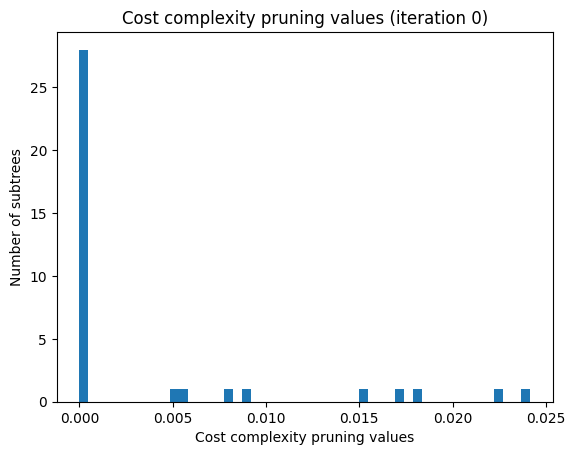

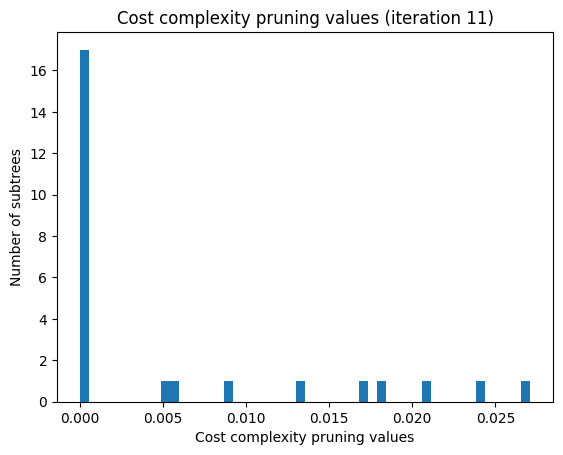

 20%|██        | 2/10 [00:01<00:04,  1.69it/s]/tmp/ipykernel_91102/1358259219.py:44: RuntimeWarning: invalid value encountered in scalar divide
  ccps[node_id] = (node_impurity - sum_leaves_impurities) / count_total_leaves
100%|██████████| 10/10 [00:04<00:00,  2.28it/s]
/tmp/ipykernel_91102/903246323.py:63: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(loc="upper right")


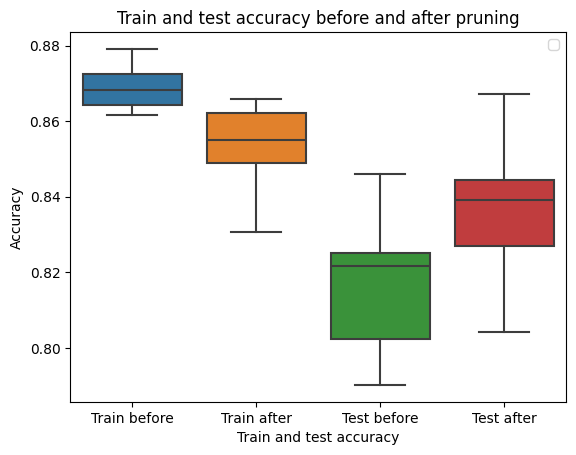

In [13]:
# TEST THE RESULTS
np.random.seed(1) # (optional) you can set a seed to reproduce the results

num_experiments = 10
num_to_prune = 12

train_acc_before, test_acc_before = [], []
train_acc_after, test_acc_after = [], []

for e in trange(num_experiments):
    # train-validation split to prune
    X_train_t, X_val_t, y_train_t, y_val_t = stratified_train_test_split(X_train, y_train, train_prop=0.8)

    # define model
    model = DecisionTreeID3(criterion=InformationGainCriterion)
    model.fit(X_train_t, y_train_t, cat_features_idx)
    train_acc_before.append(accuracy(y_train_t, model.predict(X_train_t)))
    test_acc_before.append(accuracy(y_test, model.predict(X_test)))

    # -- pruning --
    for i in range(num_to_prune):
        # Compute the cost complexity pruning values for each subtree in the validation set
        subtrees_impurities = {}
        compute_cost_complexity(X_val_t, y_val_t, 0, model, subtrees_impurities, len(X_val_t))

        # keep only the internal nodes
        subtrees_impurities = {
            node_id: imp
            for node_id, imp in subtrees_impurities.items()
            if model.nodes[node_id].feature is not None
        }

        # sort the subtrees by alpha-ccps in ascending order
        sorted_ccps = sorted(subtrees_impurities.items(), key=lambda item: item[1])
        
        if i in [0, num_to_prune-1] and e == 0:
            plt.figure()
            plt.hist([imp for _, imp in sorted_ccps], bins=50)
            plt.title(f"Cost complexity pruning values (iteration {i})")
            plt.xlabel("Cost complexity pruning values")
            plt.ylabel("Number of subtrees")
            plt.show()

        # prune the least important subtree
        prune_tree(model, ids_to_prune=[sorted_ccps[0][0]])

    train_acc_after.append(accuracy(y_train_t, model.predict(X_train_t)))
    test_acc_after.append(accuracy(y_test, model.predict(X_test)))
        

# use sns to box plot
import seaborn as sns
df = pd.DataFrame({
    "Train before": train_acc_before,
    "Train after": train_acc_after,
    "Test before": test_acc_before,
    "Test after": test_acc_after
})
sns.boxplot(data=df)
plt.title("Train and test accuracy before and after pruning")
plt.xlabel("Train and test accuracy")
plt.ylabel("Accuracy")
plt.legend(loc="upper right")
plt.show()

## Exercise 3 - Implement Random Forest with Bootstrap Aggregating
In **bootstrap aggregating** each decision tree is trained on a different random subset of the original dataset. These subsets are drawn **with replacement**.

<span style="color:red"><strong>TODO 4</strong></span>

- 🌲 Implement a **Random Forest (RF)** using **bootstrap aggregating**.
- Test it on Titanic data (using X_train, X_test, y_train and y_test from the above)

Notes: 
You don't need to modify the existing `DecisionTreeID3` class. Instead, you only need to:
- Write functions to randomly sample the training data **with replacement**
- Use these bootstrap samples to train each tree in the forest
- Predict the most frequently predicted class


In [14]:
# Functions for bootstrap aggregating

def bootstrap_sample(X, y):
    # select n samples from X with replacement
    # first parameter: values among which we are selecting, second parameter: number of values that we are 
    # selecting, third parameter: with replacement
    indices = np.random.choice(len(X), size=len(X), replace=True)
    # filter X and y based on indices
    return X[indices], y[indices]

def fit_bagging(X, y, T, categorical_features): 
    """Fit T trees using bagging"""
    # forest
    trees = []
    for j in range(T): 
        # alternative dataset
        X_sample, y_sample = bootstrap_sample(X, y)
        # initialize the tree
        tree = DecisionTreeID3(criterion=InformationGainCriterion)
        # fit the tree
        tree.fit(X_sample, y_sample, categorical_features)
        # add the tree to the forest
        trees.append(tree)
    return trees
    
def predict_bagging(X, trees): 
    # matrix where each row corresponds to a different tree (each column correspond to a different sample)
    predictions = np.array([tree.predict(X) for tree in trees]) # Shape (num_trees, num_samples)
    y_pred = []
    # iterate through the columns
    for i in range(predictions.shape[1]):
        # for column (sample) i, consider all rows (all predictions of all trees)
        sample_predictions = predictions[:, i]
        # get the number of times each class appears in the column 
        # (array containing the number of times class 0 appears, the number of times class 1 appears ...)
        class_counts = np.bincount(sample_predictions)
        # get the class that appears most frequently
        majority_class = np.argmax(class_counts)
        # add the prediction to the prediction list
        y_pred.append(majority_class)
    return np.array(y_pred)

In [15]:
np.random.seed(0) # (optional) you can set a seed to reproduce the results

# train a single tree
num_trees = 1
trees = fit_bagging(X_train, y_train, num_trees, cat_features_idx)
# get the vector of predictions
y_pred = predict_bagging(X_test, trees)
acc = accuracy(y_test, y_pred)
print(f"Accuracy: {len(trees)} trees", acc)


# train the forest
num_trees = 10
trees = fit_bagging(X_train, y_train, num_trees, cat_features_idx)
# get the vector of predictions
y_pred = predict_bagging(X_test, trees)
acc = accuracy(y_test, y_pred)
print(f"Accuracy: {len(trees)} trees", acc)

Accuracy: 1 trees 0.7972027972027972
Accuracy: 10 trees 0.8111888111888111


## Exercise 4 - Add Feature Bagging
In **Feature bagging**, at each split in the decision tree, the algorithm selects the best feature from a random subset of available features.

**Key Concepts**:

- **Subsampling Without Replacement:**  
  At each split, a random subset of features is selected **without replacement** from the available features.

- **CART Trees:**  
  In the CART algorithm, the standard approach is to randomly select $\sqrt{p}$ features at each split, where $p$ is the total number of features in the dataset.

- **ID3 Trees:**  
  In the case of ID3, the situation is different because once a feature is used in a split, it is no longer available for use in subsequent splits, in the same branch.

  Therefore, when applying feature bagging to ID3:
  - At each split, you should randomly select $\sqrt{p'}$ features among the available features,
  - where $p'$ is the number of **remaining (available)** features — i.e., the ones that have **not** been used yet in the current branch of the tree.


<span style="color:red"><strong>TODO 5</strong></span>

🎒 Modify the `DecisionTreeID3` class for feature bagging. 

In [16]:
# we inherit the DecisionTree class and modify the find_best_split method and the constructor
class DecisionTreeFeatureBaggingID3(DecisionTreeID3):     # we are inherinting all attributes and methods from DecisionTree 
    def _best_split(self, X, y, mask_feature): 
        """Select the best feature as the one that yields highest information gain.
        
        Returns: 
            tuple (int, float): (best_feature, best_impurity
        """
        available_features = np.where(mask_feature)[0]
        if len(available_features) == 0: 
            raise ValueError("No features available for splitting. Leaf condition failed. Check the code")
        
        # Sample √(p') = sqrt(number of available features)
        n_features_to_sample = max(1, int(np.sqrt(len(available_features))))
        sampled_features = np.random.choice(available_features, n_features_to_sample, replace=False)
        
        best_feature = None 
        best_impurity = -np.inf if self.criterion.OPTIMIZATION == "maximize" else np.inf
        for feature in sampled_features: 
            is_categorical = feature in self.categorical_features
            _, y_subsets, _ = self._split_dataset(X, y, feature, is_categorical)
            impurity = self.criterion.split_impurity(y_subsets)
            if self.criterion.OPTIMIZATION == "minimize":
                is_better = impurity < best_impurity
            else:
                is_better = impurity > best_impurity
            if is_better:
                best_impurity = impurity
                best_feature = feature
                
        return best_feature, best_impurity

In [17]:
# example, the number of trees in the forest is fixed, we vary the depth of the trees
forest_sizes = 4
tree = DecisionTreeFeatureBaggingID3(criterion=InformationGainCriterion)
tree.fit(X_train, y_train, cat_features_idx)

y_pred = tree.predict(X_test)
print("Bagging Test accuracy:", accuracy(y_test, y_pred))

Bagging Test accuracy: 0.7902097902097902


<span style="color:red"><strong>TODO 6</strong></span>

Evaluate the effect of forest size on the random forest performance using the Titanic dataset. For each forest size $ T \in \{2, 4, 8, 16, 32\} $, perform 5 trials in which you train a random forest (with feature bagging) of size $ T $ on the training set, and compute the prediction accuracy on the test set. For each value of $ T $, calculate the mean and standard deviation of the accuracy across the 5 trials using numpy functions. Then, plot the mean accuracy against the number of trees in the forest.

How does accuracy evolve as the number of trees increases? Provide a brief explanation for the trend you observe.

> **Note:** In the labs, we used `trange` to manage loops; feel free to skip that now.


Trials: 100%|██████████| 5/5 [00:33<00:00,  6.72s/it]


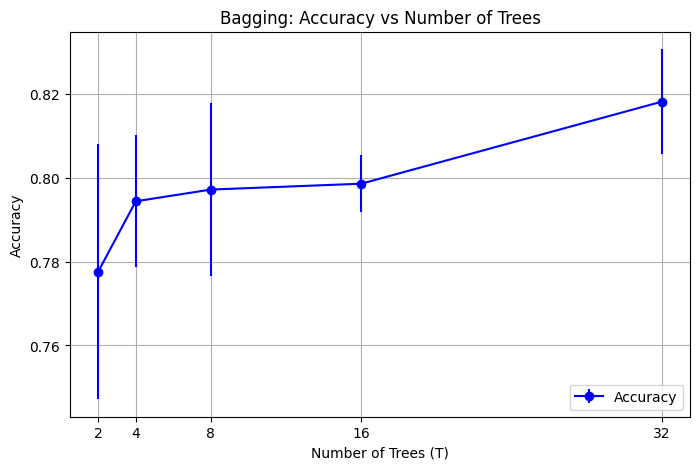

In [18]:
from tqdm import trange  # to print a progress bar

np.random.seed(0) # (optional) you can set a seed to reproduce the results

# redefine the fit_bagging function to use the new class 
def fit_bagging_feature_bagging(X, y, T): 
    """Fit T trees using bagging and Decision Tree with feature baggingS"""
    trees = []
    for j in range(T): 
        X_sample, y_sample = bootstrap_sample(X, y)
        tree = DecisionTreeFeatureBaggingID3(criterion=InformationGainCriterion)
        tree.fit(X_sample, y_sample, cat_features_idx)
        trees.append(tree)
    return trees

# we make the same computation several times, reporting the mean and variance of the accuracy metric
trials = 5
# number of trees in the forest
T_sizes = [2, 4, 8, 16, 32]

trial_accuracies = []
for trial in trange(trials, desc="Trials", leave=True): # while this loop is computed, print a progress bar
    accuracies = []
    for T in T_sizes:
        # train the forest
        trees = fit_bagging_feature_bagging(X_train, y_train, T)
        # get the vector of predictions
        y_pred = predict_bagging(X_test, trees)
        # compute the accuracy
        acc = accuracy(y_test, y_pred)
        accuracies.append(acc)
    trial_accuracies.append(accuracies)

# Calculate mean and std of accuracies
mean_accuracies = np.mean(trial_accuracies, axis=0)
std_accuracies = np.std(trial_accuracies, axis=0)

# Plot accuracies over T_sizes with error bars
plt.figure(figsize=(8, 5))
plt.errorbar(
    T_sizes, mean_accuracies, yerr=std_accuracies, fmt="o-", color="b", label="Accuracy"
)
plt.xlabel("Number of Trees (T)")
plt.ylabel("Accuracy")
plt.title("Bagging: Accuracy vs Number of Trees")
plt.grid(True)
plt.xticks(T_sizes)
plt.legend(loc="lower right")
plt.show()

## Exercise 5 - ROC Curve in Random Forests

**ROC Receiver Operating Characteristic**

> <span style="color:red"><strong>Note</strong></span>
> In this exercise, we are predicting a binary class (0 or 1). The ROC curve is not (directly) applicable to multi-class classification problems.

The **ROC curve** plots the **True Positive Rate (TPR)** against the **False Positive Rate (FPR)** across various decision threshold values.

A classifier that performs well will have a curve that bows toward the top-left corner, indicating a high TPR and low FPR.

**Decision Threshold and Customization**

In a **Random Forest**, each tree votes for a class, and the final prediction is based on majority vote. The **confidence** returned by our `predict_bagging` function represents the proportion of trees voting for the predicted class.

We can compute a **score** (i.e., the probability assigned to class $1$) as:

$$
\text{score} = \begin{cases}
\text{confidence} & \text{if predicted\_class} = 1 \\
1 - \text{confidence} & \text{if predicted\_class} = 0
\end{cases}
$$

By default, the decision threshold is **0.5**:
- Class 1 is predicted if more than half of the trees vote for it.
- Equivalently, class 1 is predicted when $\text{score} \geq 0.5$.

However, this threshold can be adjusted based on the cost of errors in your application:

- **If False Positives are costly**:  
  Increase the threshold (e.g., to 0.8) so class 1 is only predicted when the model is highly confident.

- **If False Negatives are more serious**:  
  Decrease the threshold (e.g., to 0.3) to make the model more likely to classify uncertain cases as class 1.

<span style="color:red"><strong>TODO 7</strong></span>

- Train a Random Forest on the **Titanic dataset** with 100 trees using your `fit_bagging_feature_bagging` function, and get the predictions on the test set using the `predict_bagging` function.  
- Use the `confidences` returned by `predict_bagging` to compute the **score** for each prediction.
- For different values of the decision threshold, compute the **True Positive Rate (TPR)** and **False Positive Rate (FPR)** based on the scores.
- Store all TPRs and FPRs in lists and plot the TPRs against the FPRs to generate the **ROC curve**.



In [19]:
# Modify the predict_bagging function to return the confidence of the predictions

def predict_bagging(X, trees): 
    # matrix where each row corresponds to a different tree (each column correspond to a different sample)
    predictions = np.array([tree.predict(X) for tree in trees]) # Shape (num_trees, num_samples)
    y_pred = []
    confidences = []
    # iterate through the columns
    for i in range(predictions.shape[1]):
        # for column (sample) i, consider all rows (all predictions of all trees)
        sample_predictions = predictions[:, i]
        # get the number of times each class appears in the column 
        # (array containing the number of times class 0 appears, the number of times class 1 appears ...)
        class_counts = np.bincount(sample_predictions)
        # get the class that appears most frequently
        majority_class = np.argmax(class_counts)
        # we compute the confidence interval as the proportion of times that the majority class gets predicted
        confidence = class_counts[majority_class] / len(trees)
        # add the prediction to the prediction list
        y_pred.append(majority_class)
        # add the confidence to the confidence list
        confidences.append(confidence)
    return np.array(y_pred), np.array(confidences)

In [20]:
T = 100
# train the forest
trees = fit_bagging_feature_bagging(X_train, y_train, T)
# get the vector of predictions
y_pred, confidences = predict_bagging(X_test, trees)
print(confidences)

[0.69 1.   0.52 0.69 1.   0.9  0.99 0.93 0.88 0.98 0.53 1.   0.65 1.
 0.83 1.   0.98 0.71 0.56 0.79 1.   0.66 1.   1.   1.   1.   0.98 0.96
 0.72 0.55 1.   1.   0.85 0.91 1.   0.78 0.98 0.84 1.   0.97 0.55 0.96
 1.   0.65 0.98 1.   0.98 0.91 0.99 0.85 1.   1.   1.   0.99 1.   0.95
 0.7  0.98 0.83 0.95 0.57 0.98 1.   1.   1.   1.   0.88 1.   0.85 0.52
 0.84 1.   0.71 1.   0.98 0.98 0.77 0.99 0.99 0.91 0.98 0.51 1.   0.94
 0.95 1.   1.   0.68 0.99 0.54 1.   1.   0.71 1.   1.   0.76 1.   0.92
 0.52 0.95 0.89 0.57 0.68 1.   0.97 0.99 0.63 1.   1.   0.62 0.96 0.94
 1.   1.   0.9  0.9  0.91 0.98 0.86 0.87 1.   1.   0.83 0.58 0.99 0.76
 1.   0.84 0.7  0.99 0.8  0.96 0.95 1.   1.   0.85 0.92 1.   0.73 0.92
 0.86 0.91 0.8 ]


In [21]:
# Ensure the score always means "confidence of class 1"
true_class1_scores = np.where(y_pred == 1, confidences, 1 - confidences)

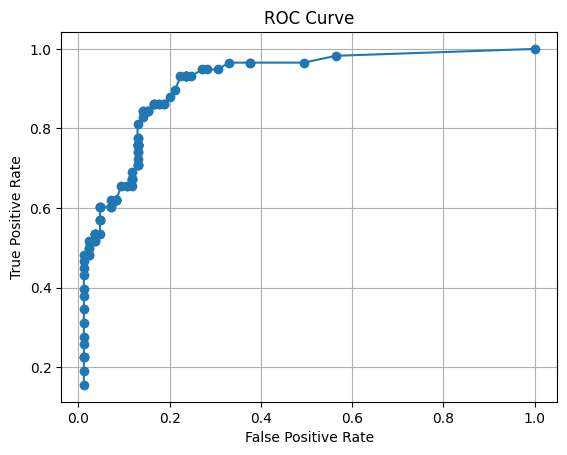

In [22]:
# Plot the ROC curve
import matplotlib.pyplot as plt

thresholds = np.arange(0.0, 1.0, 0.01)
tpr_list = []
fpr_list = []

for threshold in thresholds:
    # predict class labels based on current threshold
    y_pred_threshold = (true_class1_scores >= threshold).astype(int)

    # compute confusion matrix components
    TP = np.sum((y_pred_threshold == 1) & (y_test == 1))
    FP = np.sum((y_pred_threshold == 1) & (y_test == 0))
    FN = np.sum((y_pred_threshold == 0) & (y_test == 1))
    TN = np.sum((y_pred_threshold == 0) & (y_test == 0))

    # compute rates
    TPR = TP / (TP + FN) if (TP + FN) > 0 else 0
    FPR = FP / (FP + TN) if (FP + TN) > 0 else 0

    tpr_list.append(TPR)
    fpr_list.append(FPR)

plt.plot(fpr_list, tpr_list, marker='o')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.grid(True)
plt.show()
    

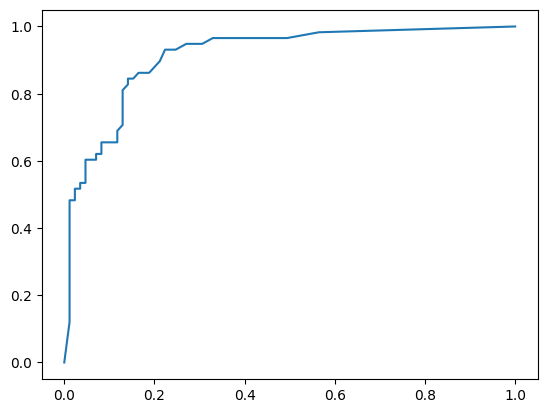

In [23]:
from sklearn.metrics import roc_curve, auc
fpr, tpr, _ = roc_curve(y_test, true_class1_scores)
plt.plot(fpr, tpr)

### Area Under the Curve (AUC)

The **higher** the ROC curve arches toward the top-left corner, the better the model is at distinguishing between the two classes. A **high Area Under the Curve (AUC)** indicates strong classification performance:

- AUC close to **1** → excellent performance  
- AUC around **0.5** → model performs no better than random guessing

We will use a custom function to compute the AUC from the `fpr_list` and `tpr_list` previously defined.  
For validation, we also compare this with the result from Scikit-learn’s `roc_auc_score`, which takes the ground truth labels and the predicted scores as inputs.

In [24]:
from numpy import trapz
# Zip and sort the points by FPR (ascending)
points = sorted(zip(fpr_list, tpr_list))
fpr_sorted, tpr_sorted = zip(*points)

# Compute AUC using trapezoidal rule
auc_score = trapz(tpr_sorted, fpr_sorted)
print(f"AUC: {auc_score:.4f}")

AUC: 0.9114


In [25]:
from sklearn.metrics import roc_auc_score

# true_class1_scores is already defined
auc_sklearn = roc_auc_score(y_test, true_class1_scores)
print(f"AUC (sklearn): {auc_sklearn:.4f}")

AUC (sklearn): 0.9123


## Exercise 6 - Include class probabilities in Decision Trees

To enhance the `DecisionTreeID3` class, we need to compute the probability (confidence) of a sample belonging to class 1 for each node. Specifically, this probability is the proportion of samples in a node that have a ground truth label of 1.

By including this probability, we can gain insights into the model's certainty about its predictions and use it for tasks such as adjusting decision thresholds or computing the ROC curve.


<span style="color:red"><strong>TODO 8</strong></span> 

Modify the `DecisionTreeID3` to compute also probabilities. 

Steps: 
1. **Compute Probability at Each Node:** 
   - For each node, calculate the proportion of samples with the class label 1 (ground truth). This will be stored as `prob_class_1`.
2. **Focus on Leaf Nodes:** 
   - While the probability is computed for every node, we are particularly interested in the probabilities associated with **leaf nodes**. These are the final nodes in the tree that give the classification result.
3. **Class Probability Storage:** 
   - Store the computed probability in the node's attributes, ensuring that leaf nodes hold the relevant information. The probability can then be used to make predictions or evaluate model confidence.


In [26]:
@dataclass
class NodeP: 
    feature: int | None                 # None if leaf
    impurity: float | None              # None if leaf
    prediction: float | None            # Not None even if not leaf (we need to retrive the parent prediction)
    parent_id: int | None               # None if root
    children : None                     # None if leaf . Dictionary of {feature_value: child_node_id}  
    prob_class_1: float | None          # Empirical probability of class 1 in this node


class DecisionTreeID3P(DecisionTreeID3): 
    # we are copying all the methods from DecisionTreeID3 and modifying the needed ones

    def _build_tree(self, X, y, depth, node_id, features_mask, parent_id):
        """Construct recursively the tree
        
        Args: 
            X (np.ndarray): input samples arriving at the node
            y (np.ndarray): target values arriving at the node
            depth (int): current depth of the node in the tree
            node_id (int): id of the node in the tree
            features_mask (np.ndarray): boolean array indicating which features are still available for splitting
            parent_id (int): id of the parent node
        """
        y_unique = np.unique(y)

        # NOTE: remember we are dealing with binary classification
        # empirical probability of class 1
        prob_class_1 = np.sum(y == 1) / len(y) if len(y) > 0 else None

        # -- LEAF CONDITIONS --
        if len(y) == 0: 
            # 1. No samples left: predict the parent class
            prediction = self.nodes[parent_id].prediction
            parent_prob = self.nodes[parent_id].prob_class_1
            self.nodes[node_id] = NodeP(feature=None, impurity=None, prediction=prediction, parent_id=parent_id, children=None, prob_class_1=parent_prob)
            return
        elif len(y_unique) == 1: 
            # 2. Pure node: only one class in y
            self.nodes[node_id] = NodeP(feature=None, impurity=None, prediction=y_unique[0], parent_id=parent_id, children=None, prob_class_1=prob_class_1)
            return
        elif np.sum(features_mask) == 0: 
            # 3. No features left: predict majority class
            prediction = np.bincount(y).argmax()
            self.nodes[node_id] = NodeP(feature=None, impurity=None, prediction=prediction, parent_id=parent_id, children=None, prob_class_1=prob_class_1)
            return
        
        # -- INTERNAL NODE: find the best feature among the available ones ---
        best_feature, best_impurity = self._best_split(X, y, features_mask)
        is_categorical = best_feature in self.categorical_features

        features_mask[best_feature] = False
        prediction = np.bincount(y).argmax()

        self.nodes[node_id] = NodeP(feature=best_feature, impurity=best_impurity, prediction=prediction, parent_id=parent_id, children=dict(), prob_class_1=prob_class_1)

        # -- Create children --
        X_subsets, y_subsets, split_values = self._split_dataset(X, y, best_feature, is_categorical)
        for i in range(len(X_subsets)):
            X_child = X_subsets[i]
            y_child = y_subsets[i]
            split_val = split_values[i]

            child_node_id = self.node_counter + 1
            self.node_counter += 1
            self.nodes[node_id].children[split_val] = child_node_id
            self._build_tree(X_child, y_child, depth + 1, child_node_id, features_mask.copy(), node_id)


    def predict_proba(self, X):
        """
        Predict the probabilities of class 1 for the given input data X.
        
        Args: 
            X (np.ndarray): input data to predict, shape (n_samples, n_features)
        
        Returns:
            np.ndarray: predicted probabilities of class 1, shape (n_samples,)
        """
        probs = []
        for x in X:
            node_id = 0
            node = self.nodes[0]
            while True: 
                if node.children is None:    # check for leaf node
                    probs.append(node.prob_class_1)
                    break 
                # else we need to go down the tree  
                feature_idx = node.feature
                feature_value = x[feature_idx]

                # check if we 
                found = False
                for key, child_id in node.children.items(): 
                    if isinstance(key, tuple): # continous feature: interval
                        lower, upper = key
                        if lower < feature_value <= upper: 
                            node_id = child_id
                            node = self.nodes[node_id]
                            found = True
                            break
                    else: # categorical feature: exact match
                        if feature_value == key: 
                            node_id = child_id
                            node = self.nodes[node_id]
                            found = True
                            break
                    
                if not found:
                    # for unseen feature values, use the current prediction
                    probs.append(node.prob_class_1)
                    break
        return np.array(probs)


## Exercise 7 - ROC of a Single Decision Tree

Now that our decision tree model provides a confidence score for class 1, we can use these scores to compute the **ROC curve** and the **AUC**.

<span style="color:red"><strong>TODO 9</strong></span> 

- Fit a **Decision Tree** on the training set of the **Titanic dataset**.  
- Use the trained model to get **predictions** and **scores** on the test set.
- For a range of **threshold values**, compute the **True Positive Rate (TPR)** and **False Positive Rate (FPR)** based on the test scores.
- Save the TPRs and FPRs in lists and **plot the ROC curve** by plotting TPRs against FPRs.


In [27]:
# Use the extended class with predict_proba
dt_id3 = DecisionTreeID3P(criterion=InformationGainCriterion)
dt_id3.fit(X_train, y_train, cat_features_idx)

# Test set
y_pred = dt_id3.predict(X_test)
# we compute the scores as the probability of class 1 of the leaf where the sample ends up
test_scores = dt_id3.predict_proba(X_test)
print(f"Accuracy: {accuracy(y_test, y_pred)}")
print(f"Test Scores (proba class 1): {test_scores[:20]}")

Accuracy: 0.8251748251748252
Test Scores (proba class 1): [1.         0.13714286 0.45454545 0.         1.         0.14285714
 0.         0.10169492 1.         0.23076923 0.56521739 0.
 0.56521739 0.14285714 1.         0.14285714 0.14285714 0.88235294
 0.45454545 1.        ]


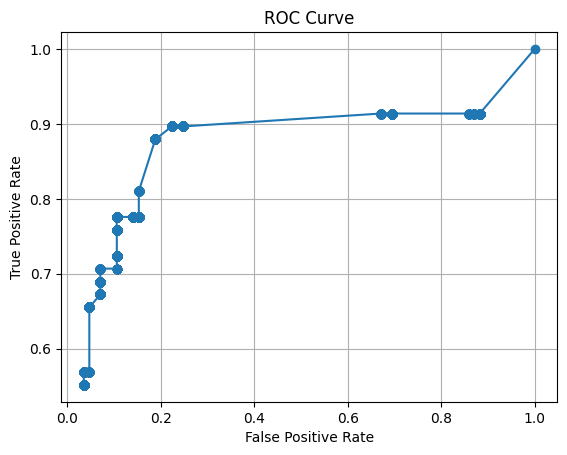

In [28]:
#given a set of possible thresholds, we plot the true positive rate against the false positive rate
thresholds = np.arange(0.0, 1.0, 0.0001)
tpr_list = []
fpr_list = []

for threshold in thresholds:
    # predict class labels based on current threshold
    y_pred_threshold = (test_scores >= threshold).astype(int)

    # compute confusion matrix components
    TP = np.sum((y_pred_threshold == 1) & (y_test == 1))
    FP = np.sum((y_pred_threshold == 1) & (y_test == 0))
    FN = np.sum((y_pred_threshold == 0) & (y_test == 1))
    TN = np.sum((y_pred_threshold == 0) & (y_test == 0))

    # compute rates
    TPR = TP / (TP + FN) if (TP + FN) > 0 else 0
    FPR = FP / (FP + TN) if (FP + TN) > 0 else 0

    tpr_list.append(TPR)
    fpr_list.append(FPR)

plt.plot(fpr_list, tpr_list, marker='o')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.grid(True)
plt.show()

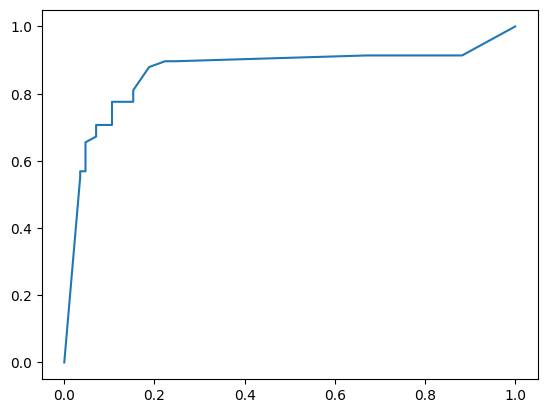

In [29]:
from sklearn.metrics import roc_curve, auc
fpr, tpr, _ = roc_curve(y_test, test_scores)
plt.plot(fpr, tpr)

### ROC-AUC of a single Decision Tree
Here, we use the same functions as before to compute the area under the ROC curve (AUC).

In [30]:
# we print the Area Under the Curve (AUC)
# Zip and sort the points by FPR (ascending)
points = sorted(zip(fpr_list, tpr_list))
fpr_sorted, tpr_sorted = zip(*points)

# Compute AUC using trapezoidal rule
auc_score = trapz(tpr_sorted, fpr_sorted)
print(f"AUC: {auc_score:.4f}")

AUC: 0.8555


In [31]:
from sklearn.metrics import roc_auc_score

# true_class1_scores is already defined
auc_sklearn = roc_auc_score(y_test, test_scores)
print(f"AUC (sklearn): {auc_sklearn:.4f}")

AUC (sklearn): 0.8652
